# LISA: sensitivity, response, and the global fit

**FQCP 2026 · Bayesian parameter estimation for gravitational-wave sources**

> Google Colab worksheet for early-stage graduate students. Run from top to
> bottom. In the JupyterBook, **Live route** cards identify the material for the
> session; **Extension** sections may be skipped live.

## Goal and analysis map

This notebook follows the LISA Analysis Tools Workshop progression:

$$
\text{sensitivity}\rightarrow\text{TDI data}\rightarrow(a\mid b)
\rightarrow\mathrm{SNR}\rightarrow\mathcal L\rightarrow
\text{single source}\rightarrow\text{unknown overlapping catalogue}.
$$

We use `lisatools` for LISA sensitivity curves and its `AnalysisContainer`, and
JaxGB for an actual moving-constellation Galactic-binary response. You will
first calculate a frequency likelihood manually, then verify the same objects
through the LISA Analysis Tools interface. The final exercise is a miniature
version of the LATW global-fit challenge.

:::{admonition} Live route — 40 minutes
:class: tip

Use the dropdowns immediately below to separate the in-room sequence from the
reference material.
:::

:::{dropdown} In the room
Sections 1–4: moving response, sensitivity/foreground, the complications lab,
and a manual likelihood. Then follow the global-fit wheel in Section 5.
:::
:::{dropdown} Read afterwards
The Fisher extension, the package-level route in Section 4b, the realistic
miniature fit, and unknown-source-count challenge are designed for follow-up.
:::

In [ ]:
import os, sys, subprocess, importlib.util

IN_COLAB = "COLAB_RELEASE_TAG" in os.environ
needed = ("lisatools", "gpubackendtools", "jaxgb", "eryn", "wdm_transform")
if any(importlib.util.find_spec(package) is None for package in needed):
    if IN_COLAB:
        subprocess.check_call(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "-q",
                "lisaanalysistools==1.2.5",
                "gpubackendtools==0.1.1",
                "jaxgb==0.2.1",
                "astropy==7.2.0",
                "eryn==1.2.6",
                "wdm-transform==0.5.0",
            ]
        )
    else:
        raise ImportError("Install the pinned LISA requirements, or run in Colab.")

In [ ]:
import itertools
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation
from jax import config

config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", message="IProgress not found.*")
from lisatools.sensitivity import (
    A1TDISens,
    E1TDISens,
    SensitivityMatrix,
    get_sensitivity,
)
from lisatools.utils.constants import YRSID_SI
from lisaorbits import EqualArmlengthOrbits, KeplerianOrbits, LINKS
from lisaorbits.utils import emitter, receiver
from lisaconstants import c as C_SI
from jaxgb.jaxgb import JaxGB
from jaxgb.params import GBObject
from wdm_transform import (
    TimeSeries as WDMTimeSeries,
    WDM,
    wdm_inner_product,
    wdm_noise_variance,
)

rng = np.random.default_rng(20260817)
plt.style.use("seaborn-v0_8-whitegrid")


def show_animation(animation):
    # H.264 video: ~40x smaller in the notebook than one PNG per frame
    try:
        return display(HTML(animation.to_html5_video()))
    except RuntimeError:  # ffmpeg unavailable: fall back to per-frame PNGs
        return display(HTML(animation.to_jshtml()))

## 1. LISA's band and source zoo

Ground-based detectors observe roughly tens of Hz to kHz. LISA targets approximately $10^{-4}$–$10^{-1}$ Hz, containing Galactic compact binaries, massive-black-hole binaries, EMRIs, stellar-origin binaries, stochastic backgrounds, and instrument noise. Long observations make many signals overlap.

Unlike a static right-angle detector, LISA is a heliocentric triangle that cartwheels as it orbits. Six delayed one-way laser links are combined into time-delay interferometry (TDI) variables. Orbital modulation helps localisation, while finite arms create a frequency-dependent response.

:::{admonition} What is the LISA data object?
:class: important

$$\text{inter-spacecraft phase measurements}
\longrightarrow \text{delayed TDI combinations}
\longrightarrow (A,E,T)\ \text{channels}
\longrightarrow \text{response + PSD}
\longrightarrow \text{likelihood}.$$

TDI is not a cosmetic re-labelling of a strain time series: delayed link
measurements cancel laser frequency noise and define the channels whose
response and noise enter inference. In the simple likelihood below we use A and
E as independent channels; this is an analysis approximation to state and
check, not a property of every possible data product.
:::

### Why LISA parameter estimation is unusually coupled

| Feature | Typical transient LVK CBC analysis | LISA analysis |
| --- | --- | --- |
| signal duration in band | seconds to minutes for many CBCs | months to years for many sources |
| response during one signal | detector geometry often changes little | constellation motion modulates the signal |
| data channels | separated ground detectors | correlated laser links combined into TDI |
| source overlap | often analyse a short segment around one event | many persistent sources share the same bins |
| noise/foreground | PSD estimated around an event, with caveats | instrument noise and astrophysical foreground may evolve together |
| catalogue size | event trigger supplies a candidate | number of resolvable sources can be unknown |

The hard part is not that Bayes' theorem changes. The signal, response, noise,
and catalogue blocks become more strongly coupled, so fitting one source while
treating everything else as fixed can bias the residual seen by the next
source.

### What the mixed data stream looks like

These LISA Data Challenge views make the overlap concrete. The same year of
Sangria data contains persistent Galactic structure, instrument noise, and
shorter massive-black-hole-binary signals.

| Time-domain mixture | Time-frequency view |
| --- | --- |
| ![Sangria time-domain data showing instrument noise, the full Galaxy, verification binaries, and massive black-hole binaries](https://lisa-ldc.in2p3.fr/static/data/img/Sangria_TD.png) | ![Sangria time-frequency periodogram with massive-black-hole-binary signals annotated](https://lisa-ldc.in2p3.fr/static/data/img/PeriodogramAnn.png) |

*Official LDC2A Sangria illustrations from the
[LISA Data Challenge](https://lisa-ldc.in2p3.fr/). The key lesson is visual:
there is no pristine data segment belonging to only one source class.*

### 1a. Choose the orbit model

The orbit object supplies spacecraft positions, directed link vectors, and
retarded light-travel times. The default below keeps the approximately
equal-arm configuration. To regenerate the link and TDI data with flexing,
unequal arms, comment the first assignment and uncomment the second, then rerun
from this cell.

In [ ]:
year = YRSID_SI
AU = 149597870700.0

# Default executed configuration: approximately equal arms.
orbits = EqualArmlengthOrbits()

# BREATHING-ORBIT RE-RUN: comment the line above, uncomment this one, and
# rerun from here through the XYZ/AET cells below.
# orbits=KeplerianOrbits()

print(f"active orbit model: {type(orbits).__name__}")
times = np.linspace(0, year, 240)
positions = np.asarray(orbits.compute_position(times, [1, 2, 3]))
fig, ax = plt.subplots(figsize=(5.4, 5.4))
for i, label in enumerate(["spacecraft 1", "spacecraft 2", "spacecraft 3"]):
    ax.plot(positions[:, i, 0] / AU, positions[:, i, 1] / AU, label=label)
ax.plot(0, 0, "o", color="gold", mec="k", label="Sun")
ax.set(
    xlabel="heliocentric x [AU]",
    ylabel="heliocentric y [AU]",
    title="An explicit LISA orbit model",
    aspect="equal",
)
ax.legend()
plt.show()

### Fast animation: the moving constellation

The orbital motion is not decorative: it amplitude-, phase-, and frequency-modulates long-lived signals and encodes sky position. This animation uses precomputed orbit coordinates, so it remains fast in Colab.

**Predict before running:** Hold a binary fixed on the sky. Which observed
features can change during a year even if the binary itself is nearly
monochromatic, and why can those changes help localisation?

In [ ]:
orbit_frames = np.arange(0, len(times), 10)
fig, ax = plt.subplots(figsize=(5.2, 5.2))
(triangle,) = ax.plot([], [], "o-", lw=1.5)
trail_lines = [ax.plot([], [], alpha=0.35)[0] for _ in range(3)]
ax.plot(0, 0, "o", color="gold", mec="k")
ax.set(
    xlim=(-1.12, 1.12),
    ylim=(-1.12, 1.12),
    aspect="equal",
    xlabel="x [AU]",
    ylabel="y [AU]",
)


def animate_constellation(frame):
    i = orbit_frames[frame]
    current = positions[i, :, :2] / AU
    closed = np.vstack([current, current[0]])
    triangle.set_data(closed[:, 0], closed[:, 1])
    for spacecraft, line in enumerate(trail_lines):
        line.set_data(
            positions[: i + 1, spacecraft, 0] / AU,
            positions[: i + 1, spacecraft, 1] / AU,
        )
    ax.set_title(f"LISA constellation: day {times[i]/86400:.0f}")
    return (triangle, *trail_lines)


orbit_animation = FuncAnimation(
    fig, animate_constellation, frames=len(orbit_frames), interval=90
)
plt.close(fig)
show_animation(orbit_animation)

### 1b. Orbits become six directed delays

For a measurement received at time $t$ on spacecraft $j$, a photon was emitted
from spacecraft $i$ at the retarded time $t-L_{ij}(t)$, where
$L_{ij}$ is the **light-travel time in seconds**:

$$
L_{ij}(t)=t_{\rm receive}-t_{\rm emit},\qquad
\hat{\mathbf n}_{ij}(t)=
\frac{\mathbf x_j(t)-\mathbf x_i(t-L_{ij})}
{cL_{ij}(t)}.
$$

The two directions along one geometric arm are distinct links. Even an
approximately equal-arm moving constellation has small directional differences
from the constellation motion. `KeplerianOrbits` adds visible arm flexing.

In [ ]:
link_codes = np.asarray(LINKS)
link_labels = [f"{int(emitter(code))} to {int(receiver(code))}" for code in link_codes]
delay_times = np.linspace(0, year, 366)
selected_light_times = np.asarray(orbits.compute_ltt(delay_times, link_codes))

# This cheap reference comparison shows breathing without changing the active
# data-generation configuration selected above.
equal_reference = EqualArmlengthOrbits()
breathing_reference = KeplerianOrbits()
equal_delays = np.asarray(equal_reference.compute_ltt(delay_times, link_codes))
breathing_delays = np.asarray(breathing_reference.compute_ltt(delay_times, link_codes))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for column, label in enumerate(link_labels):
    axes[0].plot(
        delay_times / 86400,
        1e3 * (selected_light_times[:, column] - selected_light_times.mean()),
        label=label,
    )
axes[0].set(
    xlabel="mission time [days]",
    ylabel="delay minus six-link mean [ms]",
    title=f"Directed delays: {type(orbits).__name__}",
)
axes[0].legend(ncol=2, fontsize=7)

# Average the two directions on each geometric arm before comparing flexing.
arm_pairs = [(0, 5), (1, 4), (2, 3)]
for first, second in arm_pairs:
    axes[1].plot(
        delay_times / 86400,
        C_SI * 0.5 * (equal_delays[:, first] + equal_delays[:, second]) / 1e9,
        color="C0",
        alpha=0.65,
    )
    axes[1].plot(
        delay_times / 86400,
        C_SI * 0.5 * (breathing_delays[:, first] + breathing_delays[:, second]) / 1e9,
        color="C3",
        alpha=0.75,
    )
axes[1].plot([], [], color="C0", label="equal-arm reference")
axes[1].plot([], [], color="C3", label="breathing reference")
axes[1].set(
    xlabel="mission time [days]",
    ylabel="two-way-averaged arm length [Gm]",
    title="Keplerian model visibly breathes",
)
axes[1].legend()
fig.tight_layout()
plt.show()

print(f"active six-link delay span: {1e3*np.ptp(selected_light_times):.3f} ms")
print(f"breathing-reference delay span: {1e3*np.ptp(breathing_delays):.3f} ms")

### 1c. Generate the one-way link data

We now generate a compact **GW-only fractional-frequency link dataset** for a
single monochromatic plane wave. For the convention used here, $i\to j$ means
emitter $i$, receiver $j$, and

$$
y^{\rm GW}_{ij}(t)=\frac12
\frac{\hat{\mathbf n}_{ij}\!\cdot
\left[\mathbf h(u_j)-\mathbf h(u_i)\right]\!\cdot
\hat{\mathbf n}_{ij}}
{1-\hat{\mathbf k}\cdot\hat{\mathbf n}_{ij}},
$$

with $u_j=t-\hat{\mathbf k}\cdot\mathbf x_j(t)/c$ and
$u_i=t-L_{ij}(t)-\hat{\mathbf k}\cdot
\mathbf x_i(t-L_{ij})/c$. The two metric samples are the reception and
emission endpoints of one laser link.

This cell does not simulate the full phasemeter budget: laser, proof-mass,
optical-path, clock, and other noises are deliberately omitted so the geometry
and delay algebra remain visible.

In [ ]:
TDI_DT = 2.0
TDI_DURATION_DAYS = 0.25
TDI_START_DAY = 90.0
TDI_MARGIN = 60.0  # longer than the four nested light-time delays used below
tdi_start = TDI_START_DAY * 86400
tdi_duration = TDI_DURATION_DAYS * 86400
tdi_time_full = np.arange(
    tdi_start - TDI_MARGIN, tdi_start + tdi_duration + TDI_DT, TDI_DT
)
tdi_light_times = np.asarray(orbits.compute_ltt(tdi_time_full, link_codes))

GW_LINK_FREQUENCY = 3e-3
GW_LINK_AMPLITUDE = 1e-20
source_ra, source_dec = 1.0, 0.4
source_direction = np.array(
    [
        np.cos(source_dec) * np.cos(source_ra),
        np.cos(source_dec) * np.sin(source_ra),
        np.sin(source_dec),
    ]
)
propagation_direction = -source_direction
reference_axis = np.array([0.0, 0.0, 1.0])
polarisation_p = np.cross(propagation_direction, reference_axis)
polarisation_p /= np.linalg.norm(polarisation_p)
polarisation_q = np.cross(propagation_direction, polarisation_p)
plus_tensor = np.outer(polarisation_p, polarisation_p) - np.outer(
    polarisation_q, polarisation_q
)

link_data = {}
link_delays = {}
for column, code in enumerate(link_codes):
    emitting = int(emitter(code))
    receiving = int(receiver(code))
    light_time = tdi_light_times[:, column]
    link_vector = np.asarray(orbits.compute_unit_vector(tdi_time_full, [code]))[:, 0, :]
    receiver_position = np.asarray(orbits.compute_position(tdi_time_full, [receiving]))[
        :, 0, :
    ]
    emitter_position = np.asarray(
        orbits.compute_position(tdi_time_full - light_time, [emitting])
    )[:, 0, :]
    receiver_phase = (
        2
        * np.pi
        * GW_LINK_FREQUENCY
        * (tdi_time_full - receiver_position @ propagation_direction / C_SI)
    )
    emitter_phase = (
        2
        * np.pi
        * GW_LINK_FREQUENCY
        * (tdi_time_full - light_time - emitter_position @ propagation_direction / C_SI)
    )
    projection = (
        0.5
        * np.einsum("ni,ij,nj->n", link_vector, plus_tensor, link_vector)
        / (1 - link_vector @ propagation_direction)
    )
    pair = (emitting, receiving)
    link_data[pair] = (
        GW_LINK_AMPLITUDE
        * projection
        * (np.cos(receiver_phase) - np.cos(emitter_phase))
    )
    link_delays[pair] = light_time

plot_window = (tdi_time_full >= tdi_start) & (tdi_time_full < tdi_start + 1800)
fig, ax = plt.subplots(figsize=(10, 3.6))
for pair, series in link_data.items():
    ax.plot(
        (tdi_time_full[plot_window] - tdi_start) / 60,
        1e22 * series[plot_window],
        label=f"{pair[0]} to {pair[1]}",
    )
ax.set(
    xlabel="minutes after data start",
    ylabel=r"one-way $y_{ij}^{GW}$ [$10^{-22}$]",
    title=f"Six GW-only link measurements: {type(orbits).__name__}",
)
ax.legend(ncol=3, fontsize=8)
plt.show()

### 1d. Apply time-dependent delay operators

The basic TDI operation is not an integer array shift. Each directed link has
its own time-dependent delay:

$$
\mathcal D_{ij}a(t)=a\!\left(t-L_{ij}(t)\right).
$$

The interpolation below makes that retarded-time evaluation explicit. Nested
delays are applied one at a time; for breathing arms their order matters.

In [ ]:
def delay_link(series, pair):
    """Apply D_ij using the active orbit's time-dependent i-to-j delay."""
    query_time = tdi_time_full - link_delays[pair]
    finite = np.isfinite(series)
    return np.interp(
        query_time, tdi_time_full[finite], series[finite], left=np.nan, right=np.nan
    )


example_pair = (3, 1)
example_return = (1, 3)
link_once_delayed = delay_link(link_data[example_return], example_pair)
link_round_trip = delay_link(link_once_delayed, example_return)
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.plot(
    (tdi_time_full[plot_window] - tdi_start) / 60,
    1e22 * link_data[example_return][plot_window],
    label="raw 1 to 3 link",
)
ax.plot(
    (tdi_time_full[plot_window] - tdi_start) / 60,
    1e22 * link_once_delayed[plot_window],
    label="after D_31",
)
ax.plot(
    (tdi_time_full[plot_window] - tdi_start) / 60,
    1e22 * link_round_trip[plot_window],
    label="after D_13 D_31",
)
ax.set(
    xlabel="minutes after data start",
    ylabel=r"fractional frequency [$10^{-22}$]",
    title="A delayed link is evaluated at a retarded time",
)
ax.legend()
plt.show()

### 1e. Build Michelson $X,Y,Z$

With $y_{ij}$ denoting emitter $i\to$ receiver $j$, the first-generation
unequal-arm Michelson channel centred on spacecraft 1 is

$$
\begin{aligned}
X={}&y_{31}+\mathcal D_{31}y_{13}
+\mathcal D_{31}\mathcal D_{13}y_{21}
+\mathcal D_{31}\mathcal D_{13}\mathcal D_{21}y_{12}\\
&-y_{21}-\mathcal D_{21}y_{12}
-\mathcal D_{21}\mathcal D_{12}y_{31}
-\mathcal D_{21}\mathcal D_{12}\mathcal D_{31}y_{13}.
\end{aligned}
$$

$Y$ and $Z$ follow by cycling the spacecraft indices. The code deliberately
mirrors the equation rather than hiding the delay paths in a package call.

In [ ]:
def michelson_xyz_channel(central, first_arm, second_arm):
    """First-generation Michelson TDI centred on `central`."""
    y = lambda emitting, receiving: link_data[(emitting, receiving)]
    d = lambda values, emitting, receiving: delay_link(values, (emitting, receiving))
    positive = (
        y(second_arm, central)
        + d(y(central, second_arm), second_arm, central)
        + d(d(y(first_arm, central), central, second_arm), second_arm, central)
        + d(
            d(d(y(central, first_arm), first_arm, central), central, second_arm),
            second_arm,
            central,
        )
    )
    negative = (
        y(first_arm, central)
        + d(y(central, first_arm), first_arm, central)
        + d(d(y(second_arm, central), central, first_arm), first_arm, central)
        + d(
            d(d(y(central, second_arm), second_arm, central), central, first_arm),
            first_arm,
            central,
        )
    )
    return positive - negative


X_full = michelson_xyz_channel(1, 2, 3)
Y_full = michelson_xyz_channel(2, 3, 1)
Z_full = michelson_xyz_channel(3, 1, 2)
tdi_keep = tdi_time_full >= tdi_start
tdi_time = tdi_time_full[tdi_keep] - tdi_start
X, Y, Z = (channel[tdi_keep] for channel in (X_full, Y_full, Z_full))
assert not any(np.isnan(channel).any() for channel in (X, Y, Z))

fig, ax = plt.subplots(figsize=(10, 3.5))
show = tdi_time < 3600
for channel, label in zip((X, Y, Z), ("X", "Y", "Z")):
    ax.plot(tdi_time[show] / 60, 1e22 * channel[show], label=label)
ax.set(
    xlabel="minutes after data start",
    ylabel=r"Michelson response [$10^{-22}$]",
    title="Delayed links form XYZ",
)
ax.legend()
plt.show()

### 1f. Rotate $X,Y,Z$ into $A,E,T$

Using the same orthonormal convention as JaxGB and LISA Analysis Tools,

$$
A=\frac{Z-X}{\sqrt2},\qquad
E=\frac{X-2Y+Z}{\sqrt6},\qquad
T=\frac{X+Y+Z}{\sqrt3}.
$$

This matrix rotation is orthonormal. Calling the resulting channels
statistically independent additionally requires the appropriate symmetric
$XYZ$ noise covariance; breathing unequal arms can reintroduce A/E/T cross
spectra.

For an equal-arm constellation and wavelengths long compared with the arms,
$T$ is an approximate GW-null channel. Unequal breathing arms spoil the exact
symmetry, so uncommenting `KeplerianOrbits` above and rerunning increases the
low-frequency $T$ leakage in this first-generation construction.

In [ ]:
A = (Z - X) / np.sqrt(2)
E = (X - 2 * Y + Z) / np.sqrt(6)
T = (X + Y + Z) / np.sqrt(3)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for channel, label in zip((X, Y, Z), ("X", "Y", "Z")):
    axes[0].plot(tdi_time[show] / 60, 1e22 * channel[show], label=label)
for channel, label in zip((A, E, T), ("A", "E", "T")):
    axes[1].plot(tdi_time[show] / 60, 1e22 * channel[show], label=label)
axes[0].set(xlabel="minutes", ylabel=r"response [$10^{-22}$]", title="Michelson basis")
axes[1].set(xlabel="minutes", title="Orthogonal AET basis")
for ax in axes:
    ax.legend()
fig.tight_layout()
plt.show()

print(f"active orbit model: {type(orbits).__name__}")
for label, channel in zip(("A", "E", "T"), (A, E, T)):
    print(f"RMS {label}: {np.std(channel):.3e}")
print(f"T/A RMS ratio: {np.std(T)/np.std(A):.3e}")

:::{admonition} TDI generation boundary
:class: warning

This transparent laboratory uses GW-only links and first-generation Michelson
TDI. It demonstrates the orbit, link, retarded-delay, XYZ, and AET data objects.
It does **not** demonstrate laser-noise cancellation for a flexing constellation:
time-dependent delay operators do not commute, and production breathing-arm
data require the correctly ordered second-generation TDI combinations.
:::

## 2. Sensitivity and Galactic confusion

As in LATW Tutorial 1, start with the noise model. The unresolved Galactic foreground changes with observing time because longer data resolve and subtract more binaries.

**Predict before running:** At which frequencies should a longer observation
change the total sensitivity most: where instrumental noise dominates, or where
the unresolved Galactic foreground dominates?

In [ ]:
f_curve = np.logspace(-5, -1, 1800)
instrument = SensitivityMatrix(f_curve, [A1TDISens, E1TDISens])
one_year = SensitivityMatrix(
    f_curve, [A1TDISens, E1TDISens], stochastic_params=(1 * year,)
)
four_year = SensitivityMatrix(
    f_curve, [A1TDISens, E1TDISens], stochastic_params=(4 * year,)
)
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.loglog(f_curve, np.sqrt(instrument.sens_mat[0]), label="instrument only")
ax.loglog(f_curve, np.sqrt(one_year.sens_mat[0]), label="+ 1-year Galactic foreground")
ax.loglog(f_curve, np.sqrt(four_year.sens_mat[0]), label="+ 4-year Galactic foreground")
ax.set(
    xlabel="frequency [Hz]",
    ylabel=r"TDI A ASD [1/$\sqrt{\mathrm{Hz}}$]",
    title="Sensitivity is part of the likelihood",
)
ax.legend()
plt.show()

## 3. Real LISA data will be more complicated

| Complication | What students should ask | Analysis consequence |
| --- | --- | --- |
| data gaps and irregular availability | why is data missing; is the gap informative? | Fourier bins become coupled; windowing/inpainting/gap-aware likelihoods |
| time-varying instrument noise | is one mission-long PSD meaningful? | segmented, time-frequency, or explicitly non-stationary noise models |
| changing Galactic foreground | which binaries become resolvable with time? | foreground and catalogue must be inferred together |
| moving/breathing constellation | are delays and orbits known accurately enough? | time-dependent link response and TDI generation |
| glitches, clock/laser artefacts, calibration | can an instrumental transient mimic a source? | extra nuisance models, vetoes, robust likelihoods |
| overlapping source classes | what belongs to the residual? | global rather than source-by-source inference |
| unknown catalogue size | how many binaries are present? | trans-dimensional/RJ methods and label-switching care |

The following lightweight laboratory is intentionally editable. Change the gap, drift, and noise-growth parameters and rerun it.

In [ ]:
from scipy.signal import welch, spectrogram

# Student playground: all three controls are deliberately visible.
GAP_DAYS = (11, 14)
FREQUENCY_DRIFT = 2e-11
NOISE_GROWTH = 0.9
cadence = 60.0
mission_days = 28.0
toy_time = np.arange(0, mission_days * 86400, cadence)
sample_rate_toy = 1 / cadence
noise_scale = 1 + NOISE_GROWTH * toy_time / toy_time[-1]
phase = 2 * np.pi * (3e-3 * toy_time + 0.5 * FREQUENCY_DRIFT * toy_time**2)
continuous_data = noise_scale * rng.normal(size=toy_time.size) + 1.5 * np.sin(phase)
available = ~((toy_time >= GAP_DAYS[0] * 86400) & (toy_time < GAP_DAYS[1] * 86400))
gapped_data = continuous_data.copy()
gapped_data[~available] = 0  # zero fill only to expose leakage below

early = continuous_data[toy_time < 7 * 86400]
late = continuous_data[toy_time > 21 * 86400]
f_early, p_early = welch(early, fs=sample_rate_toy, nperseg=4096)
f_late, p_late = welch(late, fs=sample_rate_toy, nperseg=4096)
window = np.hanning(toy_time.size)
fft_frequency = np.fft.rfftfreq(toy_time.size, cadence)
fft_full = np.abs(np.fft.rfft(window * continuous_data))
fft_gap = np.abs(np.fft.rfft(window * gapped_data))
f_spec, t_spec, p_spec = spectrogram(
    gapped_data, fs=sample_rate_toy, nperseg=2048, noverlap=1536
)

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes[0, 0].plot(toy_time[::80] / 86400, available[::80].astype(int))
axes[0, 0].set(
    xlabel="mission time [days]", ylabel="available?", title="A three-day gap"
)
axes[0, 1].loglog(f_early[1:], np.sqrt(p_early[1:]), label="week 1")
axes[0, 1].loglog(f_late[1:], np.sqrt(p_late[1:]), label="week 4")
axes[0, 1].set(
    xlabel="frequency [Hz]", ylabel="ASD [toy]", title="Noise level changes with time"
)
axes[0, 1].legend()
near = (fft_frequency > 2.7e-3) & (fft_frequency < 3.4e-3)
axes[1, 0].semilogy(1e3 * fft_frequency[near], fft_full[near], label="continuous")
axes[1, 0].semilogy(
    1e3 * fft_frequency[near], fft_gap[near], label="gap zero-filled", alpha=0.8
)
axes[1, 0].set(
    xlabel="frequency [mHz]",
    ylabel="FFT magnitude",
    title="A gap spreads power across bins",
)
axes[1, 0].legend()
band = (f_spec > 2.7e-3) & (f_spec < 3.4e-3)
image = axes[1, 1].pcolormesh(
    t_spec / 86400, 1e3 * f_spec[band], np.log10(p_spec[band] + 1e-30), shading="auto"
)
axes[1, 1].set(
    xlabel="mission time [days]",
    ylabel="frequency [mHz]",
    title="Drifting line + gap in time–frequency",
)
fig.colorbar(image, ax=axes[1, 1], label="log power")
fig.tight_layout()
plt.show()

### WDM time--frequency map and likelihood

The WDM transform gives localised real coefficients $w_{nm}$ on a
time--frequency grid. For stationary Gaussian noise and a diagonal WDM
approximation,

$$
\log \mathcal L_{\rm WDM}=-\frac12\sum_{n,m}
\frac{(w^d_{nm}-w^h_{nm})^2}{\sigma_{nm}^2}+\mathrm{constant},
\qquad
\sigma_{nm}^2=\frac{N\,S(f_m)}{2\,\Delta t}.
$$

This is the WDM counterpart of the diagonal frequency-domain Whittle
likelihood. It is useful because the map makes a drifting signal, changing
noise, and a gap visible. It is not magically exact: a gap and non-stationary
noise correlate pixels, so the diagonal form below is a controlled teaching
approximation.

In [ ]:
toy_signal = 1.5 * np.sin(phase)
WDM_NT = 280  # 28 days at 60 s cadence gives an exactly rectangular 280 x 144 grid.
wdm_data = WDM.from_time_series(WDMTimeSeries(continuous_data, dt=cadence), nt=WDM_NT)
wdm_gap = WDM.from_time_series(WDMTimeSeries(gapped_data, dt=cadence), nt=WDM_NT)
wdm_model = WDM.from_time_series(WDMTimeSeries(toy_signal, dt=cadence), nt=WDM_NT)
wdm_coeffs = np.asarray(wdm_data.coeffs[0])
wdm_gap_coeffs = np.asarray(wdm_gap.coeffs[0])
wdm_model_coeffs = np.asarray(wdm_model.coeffs[0])
wdm_nf = wdm_coeffs.shape[1] - 1
# Use the transform's own grid: the row spacing is nyquist/nf = 1/(2*nf*dt),
# not 1/(nf*dt).  Building it by hand is off by a factor of two.
wdm_frequency = np.asarray(wdm_data.freq_grid)
# Unit-variance sampled white noise has one-sided PSD 2*dt.  We deliberately use
# this stationary reference even though the toy noise grows with time.
wdm_stationary_var = wdm_noise_variance(
    np.full(wdm_nf + 1, 2 * cadence), nt=WDM_NT, nf=wdm_nf, dt=cadence
)
wdm_residual = wdm_coeffs - wdm_model_coeffs
logL_wdm = -0.5 * wdm_inner_product(wdm_residual, wdm_residual, wdm_stationary_var)
print(f"WDM grid: {WDM_NT} time pixels x {wdm_nf+1} frequency columns")
print(
    f"Diagonal stationary-noise WDM log likelihood (up to a constant): {logL_wdm:.1f}"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
show = (wdm_frequency > 2.4e-3) & (wdm_frequency < 3.7e-3)
pixel_time = np.linspace(0, mission_days, WDM_NT)
# One shared colour scale, or the two panels cannot be compared by eye.
scale = np.percentile(np.abs(wdm_coeffs[:, show]), 99.5)
for ax, coeffs, title in zip(
    axes, (wdm_coeffs, wdm_gap_coeffs), ("continuous data", "zero-filled gap")
):
    image = ax.pcolormesh(
        pixel_time,
        1e3 * wdm_frequency[show],
        np.abs(coeffs[:, show].T),
        shading="nearest",
        cmap="magma",
        vmin=0,
        vmax=scale,
    )
    ax.set(
        xlabel="mission time [days]",
        ylabel="frequency [mHz]",
        title=f"WDM coefficients: {title}",
    )
fig.colorbar(image, ax=axes, label=r"$|w_{nm}|$", pad=0.02)
plt.show()

print(f"pixel size: {wdm_data.delta_t/3600:.2f} h x {wdm_data.delta_f*1e3:.3f} mHz")
print(f"line drift over the mission: {FREQUENCY_DRIFT*toy_time[-1]*1e3:.3f} mHz")
print("Raise FREQUENCY_DRIFT until the drift exceeds one pixel and the track tilts.")

### Frequency domain versus WDM: the same inner product

Before trusting the wavelet picture, check that it is the *same analysis*. Both
domains compute one number, the noise-weighted inner product, and an orthogonal
change of basis must leave it unchanged:

$$
(h\mid h)_{\rm freq}=4\Delta f\sum_k\frac{|\tilde h_k|^2}{S(f_k)}
\qquad\text{versus}\qquad
(h\mid h)_{\rm WDM}=\sum_{n,m}\frac{w_{nm}^2}{\sigma_{nm}^2}.
$$

If those disagree, the wavelet normalisation is wrong and nothing built on top
of it can be believed. They should agree to several decimal places.

In [ ]:
from wdm_transform import matched_filter_snr_rfft, matched_filter_snr_wdm

# A clean, gap-free signal in stationary white noise, so both domains are valid.
check_psd_value = 2 * cadence  # one-sided PSD of unit-variance sampled noise
check_frequency = np.fft.rfftfreq(toy_time.size, cadence)

snr_frequency_domain = matched_filter_snr_rfft(
    np.fft.rfft(toy_signal),
    np.full(check_frequency.size, check_psd_value),
    check_frequency,
    dt=cadence,
)
snr_wdm_domain = matched_filter_snr_wdm(wdm_model_coeffs, wdm_stationary_var)

print(f"optimal SNR, frequency domain : {snr_frequency_domain:.5f}")
print(f"optimal SNR, WDM domain       : {snr_wdm_domain:.5f}")
print(f"ratio                         : {snr_wdm_domain/snr_frequency_domain:.6f}")
print("\nSame signal, same noise model, two different bases.")

### What the wavelet domain actually buys you

The two domains agree on clean, stationary data, so WDM is not a better
analysis in general. It earns its place when the *assumptions* behind the
frequency-domain likelihood fail, and both failures are on display in this
laboratory:

- **A gap is local in time, but every Fourier basis function is global.** One
  missing stretch therefore corrupts every frequency bin at once, which is the
  leakage seen earlier. In WDM the corruption is confined to the pixel columns
  that overlap the gap, so it can simply be **masked**.
- **Non-stationary noise is local in time too.** The frequency-domain Whittle
  likelihood has one $S(f)$ for the whole mission. In WDM the variance carries
  a time index, $\sigma_{nm}^2$, so a drifting noise level is just a
  column-dependent weight.

The next cell puts a number on the first point: recover the same injected
signal from gapped data, once by zero-filling in the frequency domain and once
by masking pixels in WDM.

In [ ]:
gap_pixels = (pixel_time >= GAP_DAYS[0] - wdm_data.delta_t / 86400) & (
    pixel_time <= GAP_DAYS[1] + wdm_data.delta_t / 86400
)
masked_var = wdm_stationary_var.copy()
masked_var[gap_pixels, :] = np.nan  # NaN variance drops those pixels entirely


def recovered_snr(data_coeffs, variance):
    """Matched-filter SNR of the known template against the data."""
    numerator = wdm_inner_product(wdm_model_coeffs, data_coeffs, variance)
    normalisation = np.sqrt(
        wdm_inner_product(wdm_model_coeffs, wdm_model_coeffs, variance)
    )
    return numerator / normalisation


retained = available.mean()
print(f"data retained outside the gap : {retained:.3f}")
print(f"best achievable SNR           : {snr_frequency_domain*np.sqrt(retained):6.2f}")
print()
print(
    f"complete data                 : {recovered_snr(wdm_coeffs, wdm_stationary_var):6.2f}"
)
print(
    f"gap zero-filled, no mask      : {recovered_snr(wdm_gap_coeffs, wdm_stationary_var):6.2f}"
)
print(
    f"gap masked in WDM             : {recovered_snr(wdm_gap_coeffs, masked_var):6.2f}"
)
print(
    f"\nmasked pixel columns: {gap_pixels.sum()} of {WDM_NT}"
    f" = {gap_pixels.mean():.1%} of the mission"
)

### Tracking a noise level that changes

The likelihood above deliberately used one stationary variance even though the
toy noise grows by `NOISE_GROWTH` across the mission. In the frequency domain
fixing that means segmenting the data and re-estimating a PSD per segment. In
WDM the grid is *already* segmented: each pixel column is a short stretch of
time, so the noise level per column follows from the coefficients themselves.

Estimating it from off-signal frequency rows recovers the injected growth.

In [ ]:
# Use every frequency row above the line, so the estimate is signal-free and
# averages enough pixels to be stable.
quiet_rows = (wdm_frequency > 3.8e-3) & (wdm_frequency < 8.0e-3)
column_variance = np.nanmean(wdm_coeffs[:, quiet_rows] ** 2, axis=1)
# Each column still averages only ~70 pixels, so smooth lightly over time.
smoothing = np.ones(9) / 9
column_variance = np.convolve(column_variance, smoothing, mode="same")
column_variance[:4] = column_variance[4]
column_variance[-4:] = column_variance[-5]
# Convert pixel variance back to a noise scale relative to the stationary value.
reference = np.nanmean(wdm_stationary_var[:, quiet_rows], axis=1)
recovered_scale = np.sqrt(column_variance / reference)

injected_scale = np.interp(pixel_time * 86400, toy_time, noise_scale)

fig, ax = plt.subplots(figsize=(8, 3.3))
ax.plot(pixel_time, recovered_scale, lw=1, label="recovered from WDM columns")
ax.plot(pixel_time, injected_scale, "k--", lw=2, label="injected noise scale")
ax.set(
    xlabel="mission time [days]",
    ylabel="noise level (relative)",
    title="A time-varying PSD is a column-dependent weight in WDM",
)
ax.legend()
plt.show()

slope = np.polyfit(pixel_time, recovered_scale, 1)[0] * mission_days
print(f"recovered growth across the mission : {slope:.3f}")
print(f"injected NOISE_GROWTH               : {NOISE_GROWTH:.3f}")

**Where this stops being a teaching toy.** The diagonal WDM
likelihood is an approximation, not an identity. Masking whole pixel columns
throws away slightly more data than the gap itself, gap edges leave partially
contaminated pixels, and a real analysis must decide whether to mask, taper,
inpaint, or model the missing stretch, and propagate that choice into the
uncertainties. The resolution trade is also fixed by hand here: choosing `nt`
sets the pixel aspect ratio, and a signal drifting by less than one pixel
height looks stationary no matter which basis you use.

**Do not interpret zero-filling as the recommended gap treatment.** It is used here because its spectral leakage is immediately visible. A research analysis must define how gaps, edges, non-stationarity, and missing-data uncertainty enter the likelihood.

### Suggested investigations

- Set `GAP_DAYS=(0, 0)` and verify that the leakage pattern changes.
- Increase `FREQUENCY_DRIFT`; when does a stationary single-bin model fail?
- Fit the early PSD to late data. Which likelihood assumption is violated?
- Replace the hard gap with a taper and compare leakage against loss of usable data.
- Add a short glitch inside versus outside the gap.

## 4. Inner product, SNR, and likelihood

For independent A and E channels,

$$
(a\mid b)=4\Delta f\,\mathrm{Re}\!\!\sum_{X\in\{A,E\},\,k}\!\!
\frac{a_{Xk}^*b_{Xk}}{S_X(f_k)},
\qquad\rho_{\rm opt}=\sqrt{(h\mid h)},
\qquad\log\mathcal L=-\tfrac12(d-h\mid d-h).
$$

- These are **exactly** the objects from the LVK notebook. Bayes' theorem does
  not change when the detector does.
- What changes: the instrument response, the source durations, the channels,
  the band, and the fact that the model is global rather than one source.
- $\Delta f=1/T_{\rm obs}$, so a longer mission means finer frequency
  resolution as well as more accumulated SNR.

**Predict before running:** If two frequency templates are one Fourier bin
apart, will they be distinguishable? How should that answer change with
observation time and with SNR?

In [ ]:
t_obs = 90 * 86400.0
simulator = JaxGB(orbits, t_obs=t_obs, t0=0, n=128)
source = GBObject(
    f0=np.array([3e-3]),
    fdot=np.array([1e-17]),
    A=np.array([2e-22]),
    ra=np.array([1.0]),
    dec=np.array([0.4]),
    psi=np.array([0.3]),
    iota=np.array([0.8]),
    phi0=np.array([0.2]),
    t_init=0.0,
)
parameters = source.to_jaxgb_array(t0=0)
A, E, T = simulator.get_tdi(parameters, tdi_generation=2, tdi_combination="AET")
frequency = np.asarray(
    simulator.get_frequency_grid(simulator.get_kmin(parameters[:, 0]))
)[0]
df = 1 / t_obs
template = np.stack([np.asarray(A)[0], np.asarray(E)[0]])
psd = np.stack(
    [
        get_sensitivity(frequency, sens_fn=A1TDISens, stochastic_params=(t_obs,)),
        get_sensitivity(frequency, sens_fn=E1TDISens, stochastic_params=(t_obs,)),
    ]
)


def inner(a, b):
    return 4 * df * np.real(np.sum(np.conj(a) * b / psd))


optimal_snr = np.sqrt(inner(template, template))
print(f"90-day optimal A+E SNR: {optimal_snr:.2f}")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(1e3 * frequency, np.abs(template[0]), label="A")
axes[0].plot(1e3 * frequency, np.abs(template[1]), label="E")
axes[0].set(
    xlabel="frequency [mHz]",
    ylabel="response magnitude",
    title="JaxGB second-generation TDI",
)
axes[0].legend()
axes[1].semilogy(1e3 * frequency, 4 * df * np.sum(np.abs(template) ** 2 / psd, axis=0))
axes[1].set(
    xlabel="frequency [mHz]",
    ylabel=r"contribution to $\rho^2$",
    title="PSD-weighted information by bin",
)
plt.show()

### Code studio: turn the inner product into a likelihood

Implement the Gaussian log likelihood
$\log\mathcal L=-\tfrac12(d-h\mid d-h)$ using the `inner` function above.
The checks use two limiting cases: a perfect model has zero residual, while a
zero model is worse by $\rho_{\rm opt}^2/2$.

In [ ]:
def student_lisa_log_likelihood(model, observed=template):
    # YOUR CODE HERE
    return None


perfect_logl = student_lisa_log_likelihood(template)
zero_logl = student_lisa_log_likelihood(np.zeros_like(template))
if perfect_logl is None or zero_logl is None:
    print("Your turn: construct the residual and return -0.5 times its inner product.")
else:
    np.testing.assert_allclose(perfect_logl, 0.0, atol=1e-10)
    np.testing.assert_allclose(zero_logl, -0.5 * optimal_snr**2, rtol=1e-10)
    print("check passed")

<details>
<summary>Show one possible solution</summary>

```python
def student_lisa_log_likelihood(model, observed=template):
    residual = observed - model
    return -0.5 * inner(residual, residual)
```

</details>

### Manual one-parameter likelihood

Perturb the source frequency, regenerate the moving-constellation response, and
compare optimal SNR with detected/matched SNR. A loud template can still match
the data poorly.

Watch the two scales in the plots below. The overlap between two templates
decays once they are separated by about one frequency bin, $1/T_{\rm obs}$.
The *likelihood* is narrower than that by roughly the signal-to-noise ratio,
which is why a 90-day observation pins $f_0$ to a small fraction of a bin.
Longer missions help twice over: more bins, and more SNR per source.

In [ ]:
def trial_template(f0_offset):
    """Regenerate the moving-constellation response at a shifted frequency."""
    trial = GBObject(
        f0=np.array([3e-3 + f0_offset]),
        fdot=np.array([1e-17]),
        A=np.array([2e-22]),
        ra=np.array([1.0]),
        dec=np.array([0.4]),
        psi=np.array([0.3]),
        iota=np.array([0.8]),
        phi0=np.array([0.2]),
        t_init=0.0,
    )
    kmin = int(simulator.get_kmin(parameters[:, 0])[0])
    a, e, _ = simulator.sum_tdi(
        trial.to_jaxgb_array(t0=0),
        kmin,
        kmin + simulator.n,
        tdi_generation=2,
        tdi_combination="AET",
    )
    return np.stack([np.asarray(a), np.asarray(e)])


# Two very different scales matter here. The overlap between templates decays
# over roughly a frequency bin, 1/T_obs, but the likelihood is narrower than
# that by about the signal-to-noise ratio.
wide_offsets = np.linspace(-7e-7, 7e-7, 61)
detected = []
for offset in wide_offsets:
    h = trial_template(offset)
    detected.append(inner(template, h) / np.sqrt(inner(h, h)))

offsets = np.linspace(-2e-8, 2e-8, 61)
logL, trial_templates = [], []
for offset in offsets:
    h = trial_template(offset)
    trial_templates.append(h)
    logL.append(-0.5 * inner(template - h, template - h))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(1e9 * wide_offsets, detected)
axes[0].axhline(optimal_snr, color="k", ls="--", label="optimal SNR")
axes[0].axvline(1e9 / t_obs, color="C3", ls=":", label=r"one bin, $1/T_{\rm obs}$")
axes[0].set(
    xlabel="frequency offset [nHz]",
    ylabel="detected SNR",
    title="Match falls away over about one bin",
)
axes[0].legend(fontsize=8)
axes[1].plot(1e9 * offsets, np.array(logL) - np.max(logL))
axes[1].axhline(-0.5, color="0.6", ls=":")
axes[1].set(
    xlabel="frequency offset [nHz]",
    ylabel=r"$\Delta \log \mathcal{L}$",
    title="The likelihood is far narrower still",
)
plt.show()

print(f"one frequency bin      : {1 / t_obs:.3e} Hz")
print(f"plotted likelihood span: {offsets[-1] - offsets[0]:.3e} Hz")

## Extension: Fisher forecasts for LISA

Skip this section on the live route. The preceding likelihood scan contains the
main lesson; this extension explains why a one-parameter slice can look more
precise than a marginal posterior.

$$
F_{ij}=\left(\frac{\partial h}{\partial\theta_i}\Big|
\frac{\partial h}{\partial\theta_j}\right),\qquad
\sigma_i^{\rm marginal}=\sqrt{(F^{-1})_{ii}},\qquad
\sigma_i^{\rm conditional}=1/\sqrt{F_{ii}}.
$$

- Finite differences use the full moving-constellation TDI response.
- Because amplitude is a pure scaling, $\sigma_{\ln A}=1/\rho$ is an exact check.
- The scan holds phase fixed, so it should match the **conditional** error.
- Marginalising over correlated phase broadens the frequency uncertainty by
  $1/\sqrt{1-\rho_{f_0\phi_0}^2}$.
- Fisher ellipses assume high SNR and local linearity. They cannot represent
  multiple modes, hard prior edges, or strongly curved posteriors.

In [ ]:
fisher_truth = dict(
    f0=3e-3, fdot=1e-17, A=2e-22, ra=1.0, dec=0.4, psi=0.3, iota=0.8, phi0=0.2
)


def fisher_response(**overrides):
    """TDI A and E on the fixed band, for the source with parameters replaced."""
    values = dict(fisher_truth)
    values.update(overrides)
    array = GBObject(
        **{key: np.array([value]) for key, value in values.items()}, t_init=0.0
    ).to_jaxgb_array(t0=0)
    a, e, _ = simulator.sum_tdi(
        array,
        int(simulator.get_kmin(parameters[:, 0])[0]),
        int(simulator.get_kmin(parameters[:, 0])[0]) + simulator.n,
        tdi_generation=2,
        tdi_combination="AET",
    )
    return np.stack([np.asarray(a), np.asarray(e)])


def derivative(key, step):
    """Central difference; amplitude is differentiated with respect to log A."""
    if key == "A":
        plus = fisher_response(A=fisher_truth["A"] * np.exp(step))
        minus = fisher_response(A=fisher_truth["A"] * np.exp(-step))
    else:
        plus = fisher_response(**{key: fisher_truth[key] + step})
        minus = fisher_response(**{key: fisher_truth[key] - step})
    return (plus - minus) / (2 * step)


fisher_labels = [r"$f_0$", r"$\ln A$", r"$\phi_0$"]
derivatives = [derivative("f0", 1e-9), derivative("A", 1e-3), derivative("phi0", 1e-3)]
fisher_matrix = np.array([[inner(a, b) for b in derivatives] for a in derivatives])
fisher_covariance = np.linalg.inv(fisher_matrix)

marginal_sd = np.sqrt(np.diag(fisher_covariance))
conditional_sd = 1 / np.sqrt(np.diag(fisher_matrix))
correlation = fisher_covariance / np.outer(marginal_sd, marginal_sd)

print(f"optimal SNR                 : {optimal_snr:.3f}")
print(f"sigma(ln A) from the Fisher : {marginal_sd[1]:.6f}")
print(f"1 / SNR                     : {1 / optimal_snr:.6f}")
print(f"f0-phi0 correlation         : {correlation[0, 2]:+.3f}")
print()
print(f"marginal    sigma(f0) : {marginal_sd[0]:.3e} Hz")
print(f"conditional sigma(f0) : {conditional_sd[0]:.3e} Hz")
print(f"ratio                 : {conditional_sd[0] / marginal_sd[0]:.3f}")
print(f"sqrt(1 - rho^2)       : {np.sqrt(1 - correlation[0, 2] ** 2):.3f}")

In [ ]:
# Turn the earlier one-dimensional scan into a normalised posterior and
# compare its width with both Fisher predictions.
scan_posterior = np.exp(np.array(logL) - np.max(logL))
scan_posterior /= np.trapezoid(scan_posterior, offsets)
scan_mean = np.trapezoid(scan_posterior * offsets, offsets)
scan_sd = np.sqrt(np.trapezoid(scan_posterior * (offsets - scan_mean) ** 2, offsets))

angles = np.linspace(0, 2 * np.pi, 200)
circle = np.column_stack([np.cos(angles), np.sin(angles)])
block = fisher_covariance[np.ix_([0, 2], [0, 2])]
eigenvalues, eigenvectors = np.linalg.eigh(block)

fig, (scan_ax, ellipse_ax) = plt.subplots(1, 2, figsize=(11, 3.8))
scan_ax.plot(offsets, scan_posterior, label="likelihood scan (conditional)")
gaussian = np.exp(-0.5 * (offsets / conditional_sd[0]) ** 2)
scan_ax.plot(
    offsets,
    gaussian / np.trapezoid(gaussian, offsets),
    "--",
    label="Fisher conditional",
)
wide = np.exp(-0.5 * (offsets / marginal_sd[0]) ** 2)
scan_ax.plot(offsets, wide / np.trapezoid(wide, offsets), ":", label="Fisher marginal")
scan_ax.set(
    xlabel=r"$f_0$ offset [Hz]",
    ylabel="density",
    title="Fixing a correlated parameter looks too precise",
)
scan_ax.legend(fontsize=8)

for n_sigma in (1, 2):
    ellipse = n_sigma * circle @ (eigenvectors * np.sqrt(eigenvalues)).T
    ellipse_ax.plot(ellipse[:, 0], ellipse[:, 1], color="C0")
ellipse_ax.axvline(0, color="0.7", lw=0.8)
ellipse_ax.axhline(0, color="0.7", lw=0.8)
ellipse_ax.set(
    xlabel=r"$\Delta f_0$ [Hz]",
    ylabel=r"$\Delta\phi_0$ [rad]",
    title=f"Fisher ellipse, correlation {correlation[0, 2]:+.2f}",
)
plt.show()

print(f"scan sigma(f0)        : {scan_sd:.3e} Hz")
print(f"conditional sigma(f0) : {conditional_sd[0]:.3e} Hz")
print(f"marginal sigma(f0)    : {marginal_sd[0]:.3e} Hz")

## 4b. Return to the live route: LISA Analysis Tools

The local `lisa_analysis_workshop` calls this abstraction an
`AnalysisContainer`. It bundles a `DataResidualArray` with a compatible
`SensitivityMatrix`, then exposes inner products, SNRs, and template
likelihoods. This does not replace understanding the formula—it reduces unit,
frequency-grid, and channel bookkeeping once the formula is understood.

In [ ]:
warnings.filterwarnings("ignore", category=SyntaxWarning, module=r"lisatools\..*")
from lisatools.analysiscontainer import AnalysisContainer
from lisatools.datacontainer import DataResidualArray

latw_data = DataResidualArray(template, f_arr=frequency)
latw_sensitivity = SensitivityMatrix(
    frequency,
    [A1TDISens, E1TDISens],
    stochastic_params=(t_obs,),
)
latw_analysis = AnalysisContainer(latw_data, latw_sensitivity)

best_index = int(np.argmax(logL))
offset_index = 0
latw_best_template = DataResidualArray(trial_templates[best_index], f_arr=frequency)
latw_offset_template = DataResidualArray(trial_templates[offset_index], f_arr=frequency)

latw_optimal_snr, latw_detected_snr = latw_analysis.template_snr(latw_best_template)
latw_best_log_likelihood = latw_analysis.template_likelihood(latw_best_template)
latw_offset_log_likelihood = latw_analysis.template_likelihood(latw_offset_template)

print(f"AnalysisContainer optimal SNR: {latw_optimal_snr:.2f}")
print(f"AnalysisContainer detected SNR: {latw_detected_snr:.2f}")
print(
    "log-likelihood drop for an offset template:",
    f"{latw_offset_log_likelihood - latw_best_log_likelihood:.2f}",
)

## 5. The global fit: a wheel of conditional analyses

The data contain every source class and the instrument at once:

$$
d=\sum_b h_b(\theta_b)+n(\eta).
$$

The global-fit "wheel" separates that enormous problem into communicating
blocks. Each block receives a residual with the other current models removed,

$$
r_b=d-\sum_{k\ne b}h_k(\theta_k),\qquad
p(\theta_b\mid d,\theta_{-b})\propto
\pi(\theta_b)\exp\!\left[-\frac12(r_b-h_b\mid r_b-h_b)\right].
$$

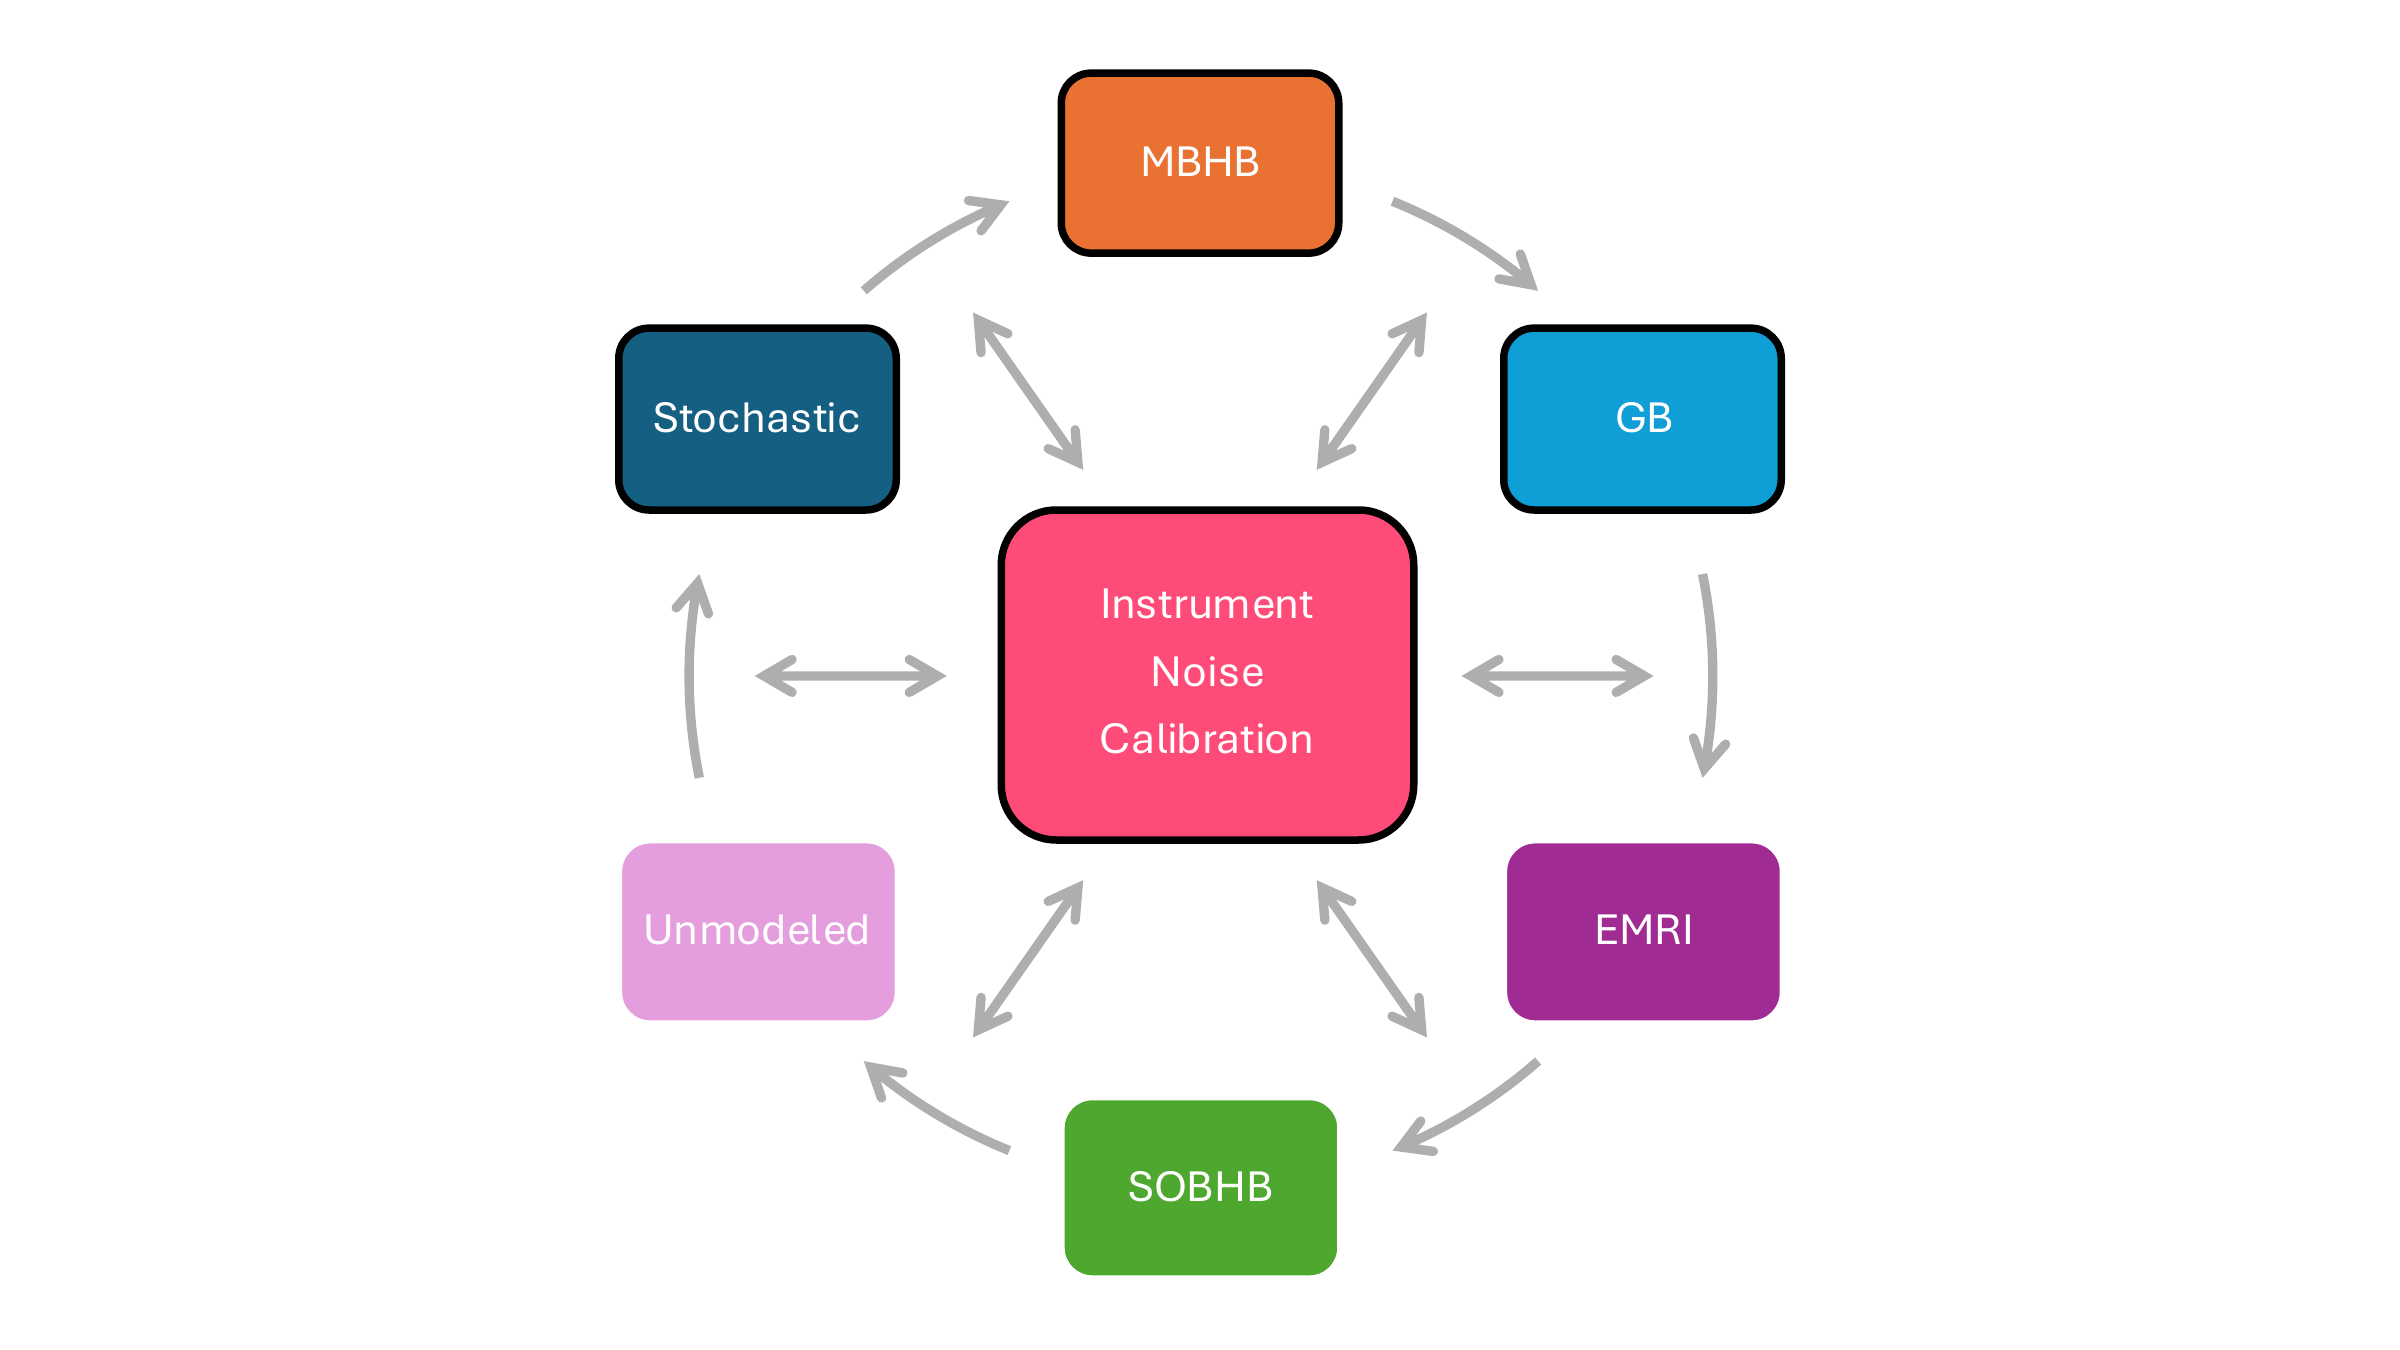

*Global Fit Wheel from Katz et al.,
[Phys. Rev. D 111, 024060 (2025)](https://doi.org/10.1103/PhysRevD.111.024060),
CC BY 4.0. The black-outlined blocks were present in the initial Erebor
implementation.*

### Gibbs versus blocked Metropolis-Hastings

One **sweep** visits every block:

1. Build block $b$'s conditional residual $r_b$.
2. Update $\theta_b$ while holding the other blocks fixed.
3. Write the updated waveform/residual back to the wheel.
4. Move to the next block; repeat the wheel many times.

- **Gibbs:** draw exactly from $p(\theta_b\mid d,\theta_{-b})$ when that
  conditional distribution is available.
- **Blocked MH:** otherwise run proposals inside the block and accept/reject
  against that same conditional target.
- The blocks are not independent fits. Repeated residual exchange propagates
  uncertainty and correlations around the wheel.
- Our three-amplitude toy below has Gaussian conditional distributions, so it
  can perform genuine Gibbs draws. Real source blocks use internal MCMC/RJMCMC
  samplers, and the unknown Galactic-binary count makes the full problem
  trans-dimensional.

**Predict before running:** If the first recovered source has a slightly
wrong amplitude, where does that mistake appear in the next source's fit? Why is
independent one-source-at-a-time fitting not a reliable global strategy?

In [ ]:
frequencies = np.array([3e-3, 3.00012e-3, 3.00025e-3])
true_scales = np.array([1.0, 0.72, 0.48])
catalogue = GBObject(
    f0=frequencies,
    fdot=np.array([1e-17, 0.5e-17, 1.5e-17]),
    A=np.full(3, 2e-22),
    ra=np.array([1.0, 1.4, 2.0]),
    dec=np.array([0.4, -0.2, 0.7]),
    psi=np.array([0.3, 0.8, 1.1]),
    iota=np.array([0.8, 1.2, 0.5]),
    phi0=np.array([0.2, 1.5, 2.4]),
    t_init=0.0,
)
all_parameters = catalogue.to_jaxgb_array(t0=0)
kmins = np.asarray(simulator.get_kmin(all_parameters[:, 0]))
kmin = int(kmins.min())
kmax = int(kmins.max() + simulator.n)
templates = []
for row in np.asarray(all_parameters):
    a, e, _ = simulator.sum_tdi(
        row[None, :], kmin, kmax, tdi_generation=2, tdi_combination="AET"
    )
    templates.append(np.stack([np.asarray(a), np.asarray(e)]))
templates = np.asarray(templates)
common_frequency = np.arange(kmin, kmax) / t_obs
common_psd = np.stack(
    [
        get_sensitivity(
            common_frequency, sens_fn=A1TDISens, stochastic_params=(t_obs,)
        ),
        get_sensitivity(
            common_frequency, sens_fn=E1TDISens, stochastic_params=(t_obs,)
        ),
    ]
)
noise = np.sqrt(common_psd / (4 * df)) * (
    rng.normal(size=common_psd.shape) + 1j * rng.normal(size=common_psd.shape)
)
data = np.sum(true_scales[:, None, None] * templates, axis=0) + noise


def global_inner(a, b):
    return 4 * df * np.real(np.sum(np.conj(a) * b / common_psd))


fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(
    1e3 * common_frequency, np.abs(data[0]), color="k", lw=0.8, label="A-channel data"
)
for i, h in enumerate(templates):
    ax.plot(
        1e3 * common_frequency, np.abs(true_scales[i] * h[0]), label=f"source {i+1}"
    )
ax.set(
    xlabel="frequency [mHz]",
    ylabel="TDI A magnitude",
    title="Overlapping JaxGB sources plus LISA noise",
)
ax.legend()
plt.show()

In [ ]:
# A one-pass subtraction is order-dependent because later blocks inherit
# the errors left by earlier ones.
sequential = np.zeros(3)
residual = data.copy()
for i, h in enumerate(templates):
    sequential[i] = global_inner(h, residual) / global_inner(h, h)
    residual -= sequential[i] * h

# Exact blocked Gibbs updates for the three amplitude coefficients. With a flat
# prior, each one-dimensional conditional posterior is Gaussian.
n_sweeps = 2000
gibbs_state = np.zeros(3)
gibbs_history = [gibbs_state.copy()]
for sweep in range(n_sweeps):
    for i, h in enumerate(templates):
        conditional_residual = (
            data
            - np.sum(gibbs_state[:, None, None] * templates, axis=0)
            + gibbs_state[i] * h
        )
        precision = global_inner(h, h)
        conditional_mean = global_inner(h, conditional_residual) / precision
        conditional_sd = 1 / np.sqrt(precision)
        gibbs_state[i] = rng.normal(conditional_mean, conditional_sd)
    gibbs_history.append(gibbs_state.copy())
gibbs_history = np.asarray(gibbs_history)
gibbs_samples = gibbs_history[400:]

# The simultaneous weighted least-squares solution is the Gaussian posterior
# mean, providing an independent check on the Gibbs chain.
whitened_templates = (
    (np.sqrt(4 * df / common_psd)[None, :, :] * templates).reshape(3, -1).T
)
whitened_data = (np.sqrt(4 * df / common_psd) * data).ravel()
design = np.vstack([whitened_templates.real, whitened_templates.imag])
target = np.r_[whitened_data.real, whitened_data.imag]
joint = np.linalg.lstsq(design, target, rcond=None)[0]

print("true             ", np.round(true_scales, 3))
print("one pass         ", np.round(sequential, 3))
print("joint mean       ", np.round(joint, 3))
print("Gibbs mean       ", np.round(gibbs_samples.mean(axis=0), 3))
print("Gibbs uncertainty", np.round(gibbs_samples.std(axis=0), 3))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for i in range(3):
    axes[0].plot(gibbs_history[:80, i], lw=1, label=f"source {i+1}")
    axes[0].axhline(true_scales[i], color=f"C{i}", ls="--", alpha=0.5)
    axes[1].hist(
        gibbs_samples[:, i],
        bins=32,
        density=True,
        histtype="step",
        color=f"C{i}",
        label=f"source {i+1}",
    )
    axes[1].axvline(joint[i], color=f"C{i}", ls="--", alpha=0.7)
axes[0].set(
    xlabel="Gibbs sweep", ylabel="amplitude multiplier", title="Conditional chains"
)
axes[1].set(
    xlabel="amplitude multiplier", ylabel="posterior density", title="Gibbs posterior"
)
for ax in axes:
    ax.legend(fontsize=8)
plt.show()

## 6. A realistic miniature global fit

The three-amplitude demo above kept the source *shapes* fixed so every
conditional was exactly Gaussian. Now we drop that: two source classes with
unknown nonlinear parameters, an unknown noise level, and no idea where the
sources are until we look.

The data model is the one from the wheel, restricted to two classes:

$$
d(f)=\underbrace{A_{\rm MBHB}\,h(f;\mathcal M,t_c,\phi_c)}_{\text{one chirp}}
+\sum_{i}\underbrace{A_i\,g(f;f_{0,i},\phi_{0,i})}_{\text{monochromatic binaries}}
+\;n(f;\eta).
$$

- **Massive black-hole binary.** A restricted post-Newtonian inspiral in the
  stationary-phase approximation, sweeping upward through the band:

$$
\tilde h(f)\propto f^{-7/6}\exp\left[i\left(2\pi f t_c-\phi_c-\frac{\pi}{4}
+\frac{3}{128}(\pi\mathcal M f)^{-5/3}\right)\right].
$$

- **Galactic binaries.** Monochromatic over the observation, so each one is a
  sinc kernel of width $1/T_{\rm obs}$ centred on $f_0$. Real GBs also drift in
  frequency and are modulated by the constellation motion; Section 4 used the
  full JaxGB response for exactly that reason.
- **Noise.** A smooth analytic LISA-like PSD with one unknown overall scale
  $\eta$, so the noise level is inferred rather than assumed.

We parametrise each source by its **signal-to-noise ratio** rather than a raw
amplitude, so the numbers are directly interpretable and the truth is known.

The pipeline is the real one, in miniature:

1. **Search.** Find the sources. Nothing is known a priori.
2. **Seed.** Use the search estimates as the starting point.
3. **Gibbs.** Cycle blocks, each conditional on the current residual.

In [ ]:
from scipy.stats import gamma as gamma_dist

T_OBS_GF = 90 * 86400.0
DF_GF = 1.0 / T_OBS_GF
K_LO, K_HI = int(2.0e-3 / DF_GF), int(6.0e-3 / DF_GF)
gf_frequency = np.arange(K_LO, K_HI) * DF_GF
N_BINS = gf_frequency.size
# A smooth, analytic stand-in for the LISA noise PSD.
BASE_PSD = 2.0e-40 * (1 + (4e-4 / gf_frequency) ** 2) + 4.0e-41
MSUN_SECONDS = 4.9254909476412675e-6


def gf_inner(a, b, psd=BASE_PSD):
    return 4 * DF_GF * np.real(np.sum(np.conj(a) * b / psd))


def gf_complex_inner(a, b, psd=BASE_PSD):
    """Complex overlap; its modulus maximises over an overall phase."""
    return 4 * DF_GF * np.sum(np.conj(a) * b / psd)


def gb_shape(f0, phi0):
    """Monochromatic source observed for a finite time: a sinc kernel."""
    return np.exp(1j * phi0) * np.sinc((gf_frequency - f0) * T_OBS_GF)


def mbhb_shape(chirp_mass, t_c, phi_c):
    """Restricted post-Newtonian inspiral, stationary-phase approximation."""
    mass_seconds = chirp_mass * MSUN_SECONDS
    phase = (
        2 * np.pi * gf_frequency * t_c
        - phi_c
        - np.pi / 4
        + (3 / 128) * (np.pi * mass_seconds * gf_frequency) ** (-5 / 3)
    )
    return gf_frequency ** (-7 / 6) * np.exp(1j * phase)


def unit_norm(shape):
    return shape / np.sqrt(gf_inner(shape, shape))


def gb_template(params):
    """params = (f0, snr, phi0). The amplitude parameter *is* the SNR."""
    return params[1] * unit_norm(gb_shape(params[0], params[2]))


def mbhb_template(params):
    """params = (chirp_mass, t_c, snr, phi_c)."""
    return params[2] * unit_norm(mbhb_shape(params[0], params[1], params[3]))


TRUE_GB = np.array(
    [[3.0004e-3, 18.0, 0.7], [3.6207e-3, 25.0, 2.1], [4.7103e-3, 12.0, 4.4]]
)
TRUE_MBHB = np.array([4.0e5, 0.55 * T_OBS_GF, 60.0, 1.1])

gf_rng = np.random.default_rng(7)
injected = sum(gb_template(g) for g in TRUE_GB) + mbhb_template(TRUE_MBHB)
gf_noise = np.sqrt(BASE_PSD / (4 * DF_GF)) * (
    gf_rng.normal(size=N_BINS) + 1j * gf_rng.normal(size=N_BINS)
)
gf_data = injected + gf_noise

print(f"analysis band: {gf_frequency[0]*1e3:.1f}-{gf_frequency[-1]*1e3:.1f} mHz")
print(f"frequency bins: {N_BINS}   bin width 1/T_obs = {DF_GF:.3e} Hz")
print(f"injected total SNR: {np.sqrt(gf_inner(injected, injected)):.1f}")
print(
    f"noise check (n|n)/N_bins = {gf_inner(gf_noise, gf_noise)/N_BINS:.3f} (expect ~2)"
)

In [ ]:
whitened_data = np.abs(gf_data) * np.sqrt(4 * DF_GF / BASE_PSD)
whitened_mbhb = np.abs(mbhb_template(TRUE_MBHB)) * np.sqrt(4 * DF_GF / BASE_PSD)

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(gf_frequency * 1e3, whitened_data, lw=0.5, color="0.6", label="data")
ax.plot(gf_frequency * 1e3, whitened_mbhb, lw=1.4, color="C3", label="MBHB (truth)")
for i, g in enumerate(TRUE_GB):
    ax.axvline(
        g[0] * 1e3,
        color="C0",
        ls="--",
        lw=1,
        label="Galactic binaries (truth)" if i == 0 else None,
    )
ax.set(
    xlabel="frequency [mHz]",
    ylabel="whitened amplitude",
    title="Everything at once: one chirp, three lines, one noise level",
)
ax.legend()
plt.show()

### Stage 1: search

Nothing above is known to the analysis. Two searches, both reusing machinery
from earlier notebooks:

- **MBHB.** Maximise the overlap over $(\mathcal M,t_c)$. Amplitude and phase
  come out analytically, and $t_c$ enters only as $e^{2\pi i f t_c}$, so **one
  inverse FFT scans every arrival time at once**. This is exactly the
  matched-filter trick from notebook 01, Section 3.
- **Galactic binaries.** After removing the MBHB estimate, a monochromatic
  source sitting exactly on a Fourier bin has all its power in that bin, so the
  search statistic is just the **whitened periodogram**. Peaks above 7 are kept.
- **Refinement.** Real sources do not sit on bin centres, so a candidate found
  at a bin loses power to leakage. A sub-bin scan recovers it. Skipping this
  step leaves the sampler stranded in the wrong Fourier bin.

In [ ]:
N_FFT = 1 << 17
tc_axis = np.arange(N_FFT) / (N_FFT * DF_GF)


def mbhb_search(residual, chirp_mass_grid):
    """Grid over chirp mass; one inverse FFT covers all coalescence times."""
    best = (-1.0, None, None, None)
    for chirp_mass in chirp_mass_grid:
        shape = mbhb_shape(chirp_mass, 0.0, 0.0)
        norm = np.sqrt(gf_inner(shape, shape))
        padded = np.zeros(N_FFT, dtype=complex)
        padded[K_LO:K_HI] = np.conj(residual) * shape / BASE_PSD
        overlap = 4 * DF_GF * N_FFT * np.fft.ifft(padded) / norm
        peak = int(np.argmax(np.abs(overlap)))
        if np.abs(overlap[peak]) > best[0]:
            best = (
                np.abs(overlap[peak]),
                chirp_mass,
                tc_axis[peak],
                np.angle(overlap[peak]),
            )
    return best


search_start = time.time()
snr_hat, mass_hat, tc_hat, phase_hat = mbhb_search(
    gf_data, np.geomspace(2.0e5, 8.0e5, 120)
)
snr_hat, mass_hat, tc_hat, phase_hat = mbhb_search(
    gf_data, np.geomspace(mass_hat * 0.97, mass_hat * 1.03, 60)
)
mbhb_seed = np.array([mass_hat, tc_hat, snr_hat, phase_hat])
print(
    f"MBHB found: SNR {snr_hat:.1f}, chirp mass {mass_hat:.4g} "
    f"(true {TRUE_MBHB[0]:.4g}), t_c/T {tc_hat/T_OBS_GF:.5f} "
    f"(true {TRUE_MBHB[1]/T_OBS_GF:.5f})"
)

residual_after_mbhb = gf_data - mbhb_template(mbhb_seed)
periodogram = np.abs(residual_after_mbhb) * np.sqrt(4 * DF_GF / BASE_PSD)
candidates, index = [], 1
while index < N_BINS - 1:
    if (
        periodogram[index] > 7.0
        and periodogram[index] >= periodogram[index - 1]
        and periodogram[index] >= periodogram[index + 1]
    ):
        candidates.append(index)
        index += 8
    else:
        index += 1

gb_seed = []
for index in candidates:
    scan = gf_frequency[index] + np.linspace(-1.5, 1.5, 121) * DF_GF
    best = (-1.0, None)
    for f0 in scan:
        shape = unit_norm(gb_shape(f0, 0.0))
        overlap = gf_complex_inner(residual_after_mbhb, shape)
        if np.abs(overlap) > best[0]:
            best = (np.abs(overlap), [f0, np.abs(overlap), np.angle(overlap)])
    gb_seed.append(best[1])
gb_seed = np.array(gb_seed)
print(
    f"\nGalactic binaries found: {len(gb_seed)}  (search took "
    f"{time.time()-search_start:.1f} s)"
)
for i, seed in enumerate(gb_seed):
    print(
        f"  f0 = {seed[0]*1e3:.6f} mHz (true {TRUE_GB[i,0]*1e3:.6f}), "
        f"SNR {seed[1]:.1f} (true {TRUE_GB[i,1]:.0f})"
    )

### Stage 2: Gibbs, one block per source

Blocks: the MBHB, each Galactic binary, and the noise level. One sweep visits
all of them; each sees only its own conditional residual.

**Proposals matter.** The MBHB parameters are correlated and fantastically
well constrained: $t_c$ is measured to a second out of a 90-day window. An
isotropic proposal is rejected essentially always. So we build the **Fisher
matrix at the seed and propose along its eigen-directions** — the payoff for
the Fisher extension in Section 4, and what production samplers actually do.

The Fisher matrix here is numerically brutal: $\sigma(f_0)\sim10^{-9}$ while
$\sigma(\rho)\sim1$, a condition number near $10^{18}$. We rescale to unit
diagonal before inverting, otherwise the amplitude errors come out meaningless.

**The noise block is a true Gibbs step.** With $\eta$ scaling the PSD,

$$
p(\eta\mid r)\propto\eta^{-N_{\rm bins}}
\exp\left[-\frac{(r\mid r)_{\rm base}}{2\eta}\right],
$$

an inverse-gamma distribution we can draw from exactly. Source blocks use
Metropolis steps — hence **Metropolis-within-Gibbs**.

In [ ]:
def fisher_proposal(template_fn, params, steps):
    """Fisher inverse, rescaled to unit diagonal for numerical stability."""
    derivatives = []
    for i in range(len(params)):
        up, down = params.copy(), params.copy()
        up[i] += steps[i]
        down[i] -= steps[i]
        derivatives.append((template_fn(up) - template_fn(down)) / (2 * steps[i]))
    fisher = np.array([[gf_inner(a, b) for b in derivatives] for a in derivatives])
    scale = np.sqrt(np.diag(fisher))
    covariance = np.linalg.inv(fisher / np.outer(scale, scale)) / np.outer(scale, scale)
    return np.linalg.cholesky(covariance) * 2.4 / np.sqrt(len(params))


mbhb_state = mbhb_seed.copy()
gb_state = gb_seed.copy()
noise_scale = 1.0
n_sources = len(gb_state)

mbhb_jump = fisher_proposal(
    mbhb_template, mbhb_state, np.array([mbhb_state[0] * 1e-5, 0.05, 0.01, 1e-3])
)
gb_jumps = [
    fisher_proposal(gb_template, g, np.array([1e-11, 0.01, 1e-3])) for g in gb_state
]
print(
    "MBHB Fisher sigma (chirp mass, t_c, SNR, phase):",
    np.round(np.sqrt(np.diag(mbhb_jump @ mbhb_jump.T)) * np.sqrt(4) / 2.4, 4),
)
print("A pure amplitude should give sigma(SNR) = 1 exactly.")

In [ ]:
N_SWEEPS, BURN_IN = 1800, 700
mbhb_model = mbhb_template(mbhb_state)
gb_models = [gb_template(g) for g in gb_state]

chain_mbhb = np.zeros((N_SWEEPS, 4))
chain_gb = np.zeros((N_SWEEPS, n_sources, 3))
chain_noise = np.zeros(N_SWEEPS)
accepted = np.zeros(1 + n_sources)
gibbs_rng = np.random.default_rng(11)


def scaled_chi_squared(residual, scale):
    return gf_inner(residual, residual) / scale


gibbs_start = time.time()
for sweep in range(N_SWEEPS):
    # --- block 1: the massive black-hole binary ---
    conditional = gf_data - sum(gb_models)
    current = scaled_chi_squared(conditional - mbhb_model, noise_scale)
    proposal = mbhb_state + mbhb_jump @ gibbs_rng.normal(size=4)
    if proposal[2] > 0:
        trial = mbhb_template(proposal)
        if np.log(gibbs_rng.uniform()) < -0.5 * (
            scaled_chi_squared(conditional - trial, noise_scale) - current
        ):
            mbhb_state, mbhb_model = proposal, trial
            accepted[0] += 1

    # --- blocks 2..N: one per Galactic binary ---
    for i in range(n_sources):
        others = mbhb_model + sum(gb_models[j] for j in range(n_sources) if j != i)
        conditional = gf_data - others
        current = scaled_chi_squared(conditional - gb_models[i], noise_scale)
        proposal = gb_state[i] + gb_jumps[i] @ gibbs_rng.normal(size=3)
        if proposal[1] > 0:
            trial = gb_template(proposal)
            if np.log(gibbs_rng.uniform()) < -0.5 * (
                scaled_chi_squared(conditional - trial, noise_scale) - current
            ):
                gb_state[i], gb_models[i] = proposal, trial
                accepted[1 + i] += 1

    # --- final block: the noise level, an exact inverse-gamma draw ---
    residual = gf_data - mbhb_model - sum(gb_models)
    noise_scale = (gf_inner(residual, residual) / 2) / gibbs_rng.gamma(N_BINS, 1.0)

    chain_mbhb[sweep] = mbhb_state
    chain_gb[sweep] = gb_state
    chain_noise[sweep] = noise_scale

print(f"{N_SWEEPS} sweeps in {time.time()-gibbs_start:.1f} s")
print("block acceptance rates:", np.round(accepted / N_SWEEPS, 2))

In [ ]:
samples_mbhb = chain_mbhb[BURN_IN:]
samples_gb = chain_gb[BURN_IN:]
samples_noise = chain_noise[BURN_IN:]


def report(name, values, truth, fmt="12.6g"):
    low, median, high = np.percentile(values, [5, 50, 95])
    flag = "ok " if low <= truth <= high else "OUT"
    print(
        f"  {name:12s}{median:{fmt}} [{low:{fmt}},{high:{fmt}}] "
        f"truth {truth:{fmt}}  {flag}"
    )


print("MBHB block")
for j, name in enumerate(["chirp mass", "t_c [s]", "SNR", "phase"]):
    report(name, samples_mbhb[:, j], TRUE_MBHB[j])
print("Galactic-binary blocks")
for i in range(n_sources):
    report(f"GB{i} f0 [mHz]", samples_gb[:, i, 0] * 1e3, TRUE_GB[i, 0] * 1e3, "12.7g")
    report(f"GB{i} SNR", samples_gb[:, i, 1], TRUE_GB[i, 1])
print("Noise block")
report("PSD scale", samples_noise, 1.0)

final_residual = gf_data - mbhb_model - sum(gb_models)
print(
    f"\nfinal (r|r)/N_bins = "
    f"{gf_inner(final_residual, final_residual)/N_BINS:.3f}  (pure noise gives ~2)"
)

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6.4))

axes[0, 0].plot(chain_mbhb[:, 0], lw=0.7)
axes[0, 0].axhline(TRUE_MBHB[0], color="k", ls="--")
axes[0, 0].axvspan(0, BURN_IN, color="C3", alpha=0.15)
axes[0, 0].set(xlabel="Gibbs sweep", ylabel="chirp mass", title="MBHB block")

for i in range(n_sources):
    axes[0, 1].plot(chain_gb[:, i, 1], lw=0.7, color=f"C{i}", label=f"GB{i}")
    axes[0, 1].axhline(TRUE_GB[i, 1], color=f"C{i}", ls="--", alpha=0.6)
axes[0, 1].axvspan(0, BURN_IN, color="C3", alpha=0.15)
axes[0, 1].set(xlabel="Gibbs sweep", ylabel="SNR", title="Galactic-binary blocks")
axes[0, 1].legend(fontsize=8, ncol=3)

axes[1, 0].hist(samples_noise, bins=40, density=True, histtype="step", color="C0")
axes[1, 0].axvline(1.0, color="k", ls="--")
axes[1, 0].set(
    xlabel=r"noise scale $\eta$",
    ylabel="posterior density",
    title="Noise block (exact Gibbs draws)",
)

axes[1, 1].plot(gf_frequency * 1e3, whitened_data, lw=0.5, color="0.7", label="data")
axes[1, 1].plot(
    gf_frequency * 1e3,
    np.abs(final_residual) * np.sqrt(4 * DF_GF / BASE_PSD),
    lw=0.5,
    color="C2",
    label="residual",
)
axes[1, 1].set(
    xlabel="frequency [mHz]", ylabel="whitened amplitude", title="All sources removed"
)
axes[1, 1].legend(fontsize=8)
fig.tight_layout()
plt.show()

:::{admonition} Residuals carry the history of a global fit
:class: warning

After subtracting one imperfect source, its remaining error is no longer
labelled “source 1”: it is structure in the residual. The next source block or
the noise block can absorb it, biasing their inferences. That is why global
methods repeatedly update shared residuals (or sample all blocks jointly), and
why “the residual looks quiet” is a necessary but not sufficient check.
:::

**Look at the GB2 trace before trusting any number.** The
weakest source (injected at SNR 12) collapses to zero amplitude early on and
stays there for several hundred sweeps before recovering. Once its amplitude
is near zero its frequency is unconstrained, so $f_0$ random-walks away and the
block has to find its way back.

- This is a genuine sampling pathology, not a plotting artefact, and it is
  common in global fits with weak sources.
- **The slowest block sets the burn-in for the whole chain.** The MBHB block
  converged within a few sweeps; GB2 needed roughly 500. Discarding a burn-in
  chosen from the MBHB trace alone would contaminate every GB2 summary.
- Production codes attack this with parallel tempering and with
  reversible-jump moves that delete and re-add sources deliberately, rather
  than waiting for a fixed-dimension chain to wander back.
- It is also the honest form of the question "is this source really there?",
  which Section 7 takes up.

What this miniature keeps from a real global fit:

- Sources are **found**, not assumed, and the fit is seeded from the search.
- Every block conditions on a residual containing the current estimate of every
  other block, so errors propagate exactly as the wheel describes.
- The noise level is inferred jointly with the signals.
- The final residual is statistically consistent with pure noise, which is the
  standard global-fit sanity check.

What it still leaves out:

- Constellation response and TDI: these are plain frequency-domain templates,
  whereas Section 4 used the real moving JaxGB response.
- Sky position, inclination, polarisation, and frequency drift $\dot f_0$.
- A **fixed** source count. Real analyses add and delete sources with
  reversible-jump moves inside the Galactic-binary block.
- Tens of thousands of overlapping sources rather than three, with a confusion
  foreground that is itself part of the noise model.
- Data gaps and non-stationarity, from Section 3.

## 7. A miniature unknown-source-count challenge

LATW Tutorial 6 uses RJMCMC so the number of Galactic binaries is inferred. Here we enumerate all eight subsets of three candidate templates and use BIC only as a fast classroom proxy—not as a replacement for evidence or RJMCMC.

In [ ]:
model_scores = []
for included_bits in itertools.product([0, 1], repeat=3):
    included = np.flatnonzero(included_bits)
    model = np.zeros_like(data)
    n_parameters = len(included)
    if n_parameters:
        X = whitened_templates[:, included]
        D = np.vstack([X.real, X.imag])
        coefficients = np.linalg.lstsq(D, target, rcond=None)[0]
        model = np.sum(coefficients[:, None, None] * templates[included], axis=0)
    minus_two_logL = global_inner(data - model, data - model)
    bic = minus_two_logL + n_parameters * np.log(target.size)
    model_scores.append((included_bits, bic))
best = min(score for _, score in model_scores)
labels = ["".join(map(str, bits)) for bits, _ in model_scores]
delta = [score - best for _, score in model_scores]
fig, ax = plt.subplots(figsize=(8, 3.3))
ax.bar(labels, delta)
ax.set(
    xlabel="included sources (1=yes)",
    ylabel=r"$\Delta$BIC",
    title="Toy catalogue-size comparison",
)
plt.show()
print(
    "Preferred subset:", labels[int(np.argmin(delta))], "(the injected subset is 111)"
)

## Extension: animate the global residual

In [ ]:
animation_sweeps = np.arange(0, 40, 2)
fig, ax = plt.subplots(figsize=(9, 3.3))
(line,) = ax.plot([], [], lw=0.8)
ax.set(
    xlim=(1e3 * common_frequency.min(), 1e3 * common_frequency.max()),
    ylim=(0, 1.1 * np.max(np.abs(data[0]))),
    xlabel="frequency [mHz]",
    ylabel="A residual magnitude",
)


def animate_residual(i):
    sweep = animation_sweeps[i]
    residual = data - np.sum(gibbs_history[sweep, :, None, None] * templates, axis=0)
    line.set_data(1e3 * common_frequency, np.abs(residual[0]))
    ax.set_title(f"shared residual after Gibbs sweep {sweep}")
    return (line,)


animation = FuncAnimation(
    fig, animate_residual, frames=len(animation_sweeps), interval=220
)
plt.close(fig)
show_animation(animation)

## Optional LISA Data Challenge input and boundary

The LDC portal requires authentication, so the live notebook uses deterministic synthetic data. An authenticated student can later upload a selected file in Colab.

```python
from google.colab import files
uploaded = files.upload()
```

This notebook uses a real sensitivity model, orbit, and TDI response, but the global exercise fits three amplitude coefficients from a fixed candidate catalogue. A research global fit must infer nonlinear parameters, source count, multiple source classes and TDI channels, instrument/foreground noise, and demonstrate convergence and coverage.

Continue with:

- local `lisa_analysis_workshop/tutorials/Tutorial1.ipynb` for sensitivity/SNR/likelihood;
- Tutorial 6 for fixed-dimensional and RJ Galactic-binary inference;
- `LATW-challenge-problem.ipynb` for an MBHB plus two trans-dimensional GB groups;
- [GLASS global analysis](https://arxiv.org/abs/2301.03673);
- [LISA Data Challenge files](https://lisa-ldc.in2p3.fr/file).

## Question bank and answer key

1. Why does a fixed LISA source acquire amplitude, phase, and frequency
   modulation during the mission, and how can that aid localisation?
2. Where should observing longer alter the total sensitivity most?
3. How do Fourier-bin separation, observing time, and SNR jointly control the
   ability to distinguish nearby frequencies?
4. Why does an imperfect source subtraction bias the rest of a global fit?
5. Why is the BIC catalogue exercise a classroom proxy rather than evidence or
   RJMCMC?
6. What is the difference between an exact Gibbs update and a blocked
   Metropolis-Hastings update?

<details>
<summary>Show the answer key</summary>

1. LISA orbits and cartwheels, changing its line of sight and delayed-link
   geometry. The resulting modulation encodes sky position and orientation.
2. The foreground-dominated part of the band changes most because longer data
   resolve and remove more Galactic binaries; instrumental noise alone is not
   reduced by resolving sources.
3. One bin, $1/T_\mathrm{obs}$, sets an overlap scale. Longer observations make
   bins narrower, while higher SNR lets the likelihood locate a frequency to a
   fraction of that scale when the model is adequate.
4. The residual retains the first source's error, so another source/noise block
   can absorb it and become biased. Global methods repeatedly communicate via a
   shared residual or sample parameters jointly.
5. BIC uses a large-sample penalty and a fixed candidate list. It does not
   integrate the prior-weighted likelihood, explore nonlinear source parameters,
   or infer an unbounded catalogue size as a trans-dimensional method does.
6. Gibbs draws directly from a block's conditional posterior. Blocked MH uses a
   proposal and an accept/reject step that leaves the same conditional posterior
   invariant. Both must repeatedly exchange updated residuals with the other
   blocks to target the joint posterior.
</details>